In [24]:
import polars as pl
import numpy as np
import datetime as dt
import sf_quant.data as sfd
import sf_quant.research as sfr
import polars_ols
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd



In [25]:
start = dt.date(1987, 1, 1)
end = dt.date(2023, 12, 31)
signal_name = "IS2"
price_filter = 5
IC = 0.05
# print(sfd.get_assets_columns())

data = sfd.load_assets(
    start=start,
    end=end,
    columns=[
        "date",
        "barrid",
        "price",
        "return",
        "specific_risk",
        "predicted_beta",
        "market_cap",
        "daily_volume", 
        "specific_return"
    ],
    in_universe=True,
).with_columns(pl.col("return",  "specific_return", "specific_risk").truediv(100))

# T=5
# days=T*21

df = data.sort(["barrid", "date"])


# calculates turnover 
df = df.with_columns(
    (pl.col("daily_volume") / pl.col("market_cap")).alias("turnover")
)

# Get last trading day of each month per stock
df = df.with_columns([
    pl.col("date").cast(pl.Datetime).alias("date_dt"),])

# Create month indicator
df = df.with_columns(
    (pl.col("date_dt").dt.year() * 100 + pl.col("date_dt").dt.month()).alias("yyyymm")
)

# does dummy variable for marketcap
df = df.with_columns(
    pl.col("market_cap")
      .rank(method="average")
      .over("date")
      .alias("rank")
).with_columns(
    (pl.col("rank") /
     pl.col("rank").max().over("date") * 3)
    .ceil()
    .alias("mktcap_bin"))

df = df.with_columns(
    pl.col("mktcap_bin").cast(pl.Utf8)
).to_dummies("mktcap_bin")


df = df.with_columns(pl.col('mktcap_bin_3.0').alias('mktb3'))
df = df.with_columns(pl.col('mktcap_bin_2.0').alias('mktb2'))
df = df.with_columns(pl.col('mktcap_bin_1.0').alias('mktb1'))
df = df.drop(['rank', 'mktcap_bin_3.0', 'mktcap_bin_2.0', 'mktcap_bin_1.0'])
# df = df.with_columns(
#     pl.col("market_cap")
#       .qcut(3)
#       .over("date")
#       .cast(pl.Utf8)
#       .alias("mktcap_bin"))

# df = df.to_dummies(columns=["mktcap_bin"])

# df = df.drop("mktcap_bin_2")


# print(df)

# # last trading day per month
monthly_df = df.group_by(["barrid", "yyyymm"]).agg([
    pl.col("specific_return").last().alias("specific_return"),
    pl.col("turnover").mean().alias("turnover"),
    pl.col("market_cap").last().alias("market_cap"),
    pl.col("price").last().alias("price"),
    pl.col("predicted_beta").last().alias("predicted_beta"),
    pl.col("specific_risk").last().alias("specific_risk"),
    pl.col("date").last().alias("date"),
    pl.col("return").last().alias("return"),
    pl.col("mktb2").last().alias("mktb2"),
    pl.col("mktb1").last().alias("mktb1")
])

monthly_df = monthly_df.with_columns(pl.col('market_cap').shift(1).alias('mktcap_lag'))

T = 12
monthly_df = monthly_df.sort(["barrid","yyyymm"])

# # current period
monthly_df = monthly_df.with_columns([
    # MOMENTUM
    pl.col("specific_return").log1p().shift(1).rolling_sum(window_size=T).over("barrid").alias("curmom"),
    
    # volitility
    pl.col("specific_return").shift(1).rolling_std(window_size=T).over("barrid").alias("curvol"),
    
    # Skewness
    pl.col("specific_return").shift(1).rolling_skew(window_size=T).over("barrid").alias("curskew"),
    
    # Turnover
    pl.col("turnover").shift(1).rolling_mean(window_size=T).over("barrid").alias("curturn")])



    # mktbin
# # previous
monthly_df = monthly_df.with_columns([
#     # MOMENTUM
    pl.col("specific_return").log1p().shift(1+T).rolling_sum(window_size=T).over("barrid").alias("prevmom"),
    
    # volitility
    pl.col("specific_return").shift(1+T).rolling_std(window_size=T).over("barrid").alias("prevvol"),
    
    # Skewness
    pl.col("specific_return").shift(1+T).rolling_skew(window_size=T).over("barrid").alias("prevskew"),
    
    # Turnover
    pl.col("turnover").shift(1+T).rolling_mean(window_size=T).over("barrid").alias("prevturn"),
    
    # mktcap
    pl.col("mktb1").shift(1).over("barrid").alias("prevmktb1"),
    pl.col("mktb2").shift(1).over("barrid").alias("prevmktb2")])

    

# # Drop rows with missing values
monthly_df = monthly_df.drop_nulls(["curmom", "curvol", "curskew", "curturn", "market_cap", "prevmom", "prevvol", "prevskew", "prevturn",'prevmktb1', 'prevmktb2'])

# # ols per mounth
def cross_sectional_ols(df_month):
    X = df_month[["prevmom", "prevvol", "prevskew", "prevturn", 'prevmktb1','prevmktb2']]
    y = df_month["curskew"]  
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    coef_dict = model.params.to_dict()
    return model

# # Shift skew by -1 month to get next month skew
# monthly_df = monthly_df.sort(["barrid","yyyymm"])
# monthly_df = monthly_df.with_columns(
#     pl.col("curskew").shift(-1).over("barrid").alias("skew_next")  
# )

# monthly_df = monthly_df.drop_nulls(["skew_next"])

# # run cross-sectional regression
coeffs_list = []
monthly= []
monthly_df = monthly_df.sort(["barrid","yyyymm"])


for month, df_month in monthly_df.group_by("yyyymm"):
    df_month_pd = df_month.to_pandas()
    model = cross_sectional_ols(df_month_pd)
    coeffs_list.append(model)
    params = model.params.to_dict()

    monthly.append([month[0], params['const'],params['prevmom'], params['prevvol'], params['prevskew'], params['prevturn'], params['prevmktb1'], params['prevmktb2']])

# # monthly1 has all of the monthly results of the regression, merges it onto monthly_df
monthly1 = pd.DataFrame(monthly, columns=['yyyymm', 'const', 'Bprevmom', 'Bprevvol', 'Bprevskew', 'Bprevturn', 'Bprevmktb1', 'Bprevmktb2'])
monthly1 = pl.from_pandas(monthly1)
monthly_df= monthly_df.join(monthly1, on='yyyymm', how='left')


avgcoeffs = monthly1[['const', 'Bprevmom', 'Bprevvol', 'Bprevskew', 'Bprevturn', 'Bprevmktb1', 'Bprevmktb2']].mean()
# print(avgcoeffs)

# # Compute expected skewness using past characteristics
monthly_df = monthly_df.with_columns(
    (
        pl.col("const")
        + pl.col("Bprevskew") * pl.col("curskew")
        + pl.col("Bprevvol") * pl.col("curvol")
        + pl.col("Bprevmom") * pl.col("curmom")
        + pl.col("Bprevturn") * pl.col("curturn")
        + pl.col("Bprevmktb1") * pl.col("mktb1")
        + pl.col("Bprevmktb2") * pl.col('mktb2')
    ).alias(signal_name)
)



In [26]:
monthly_df

barrid,yyyymm,specific_return,turnover,market_cap,price,predicted_beta,specific_risk,date,return,mktb2,mktb1,mktcap_lag,curmom,curvol,curskew,curturn,prevmom,prevvol,prevskew,prevturn,prevmktb1,prevmktb2,const,Bprevmom,Bprevvol,Bprevskew,Bprevturn,Bprevmktb1,Bprevmktb2,IS2
str,i32,f64,f64,f64,f64,f64,f64,date,f64,u8,u8,f64,f64,f64,f64,f64,f64,f64,f64,f64,u8,u8,f64,f64,f64,f64,f64,f64,f64,f64
"""USA06Z1""",201507,-0.0517,0.000292,1.1396e9,10.73,1.354733,0.428897,2015-07-31,-0.037668,1,0,1.2378e9,0.039595,0.02507,0.486143,0.000215,0.031367,0.021163,0.172437,0.000295,0,1,0.097809,-0.211056,2.540264,-0.02018,83.439224,-0.058116,-0.061459,0.099813
"""USA06Z1""",201508,0.03565,0.000312,1.0575e9,9.71,1.27402,0.440315,2015-08-31,0.011458,1,0,2.744976e8,-0.019034,0.029686,0.187701,0.000221,0.044823,0.020899,0.023918,0.000297,0,1,0.147111,0.005757,1.842877,0.015975,93.65262,-0.097748,-0.073398,0.152026
"""USA06Z1""",201509,-0.01324,0.000258,1.0510e9,9.65,1.305522,0.42671,2015-09-30,0.020085,1,0,3.6199e8,0.025207,0.031361,-0.060531,0.000233,0.063146,0.019027,0.167901,0.000298,0,1,0.125814,0.05336,0.942863,0.022902,99.405345,-0.088904,-0.022494,0.156047
"""USA06Z1""",201510,0.00098,0.000425,7.9285752e8,7.28,1.53375,0.4584342,2015-10-30,-0.001372,1,0,1.4092e10,0.024812,0.031379,-0.058059,0.000242,0.06486,0.018871,0.174956,0.000268,0,1,0.128291,-0.237619,0.838397,0.047989,125.172793,-0.100336,-0.039749,0.136471
"""USA06Z1""",201511,0.04006,0.000268,9.7629952e8,8.96,1.611564,0.46629,2015-11-30,0.026346,1,0,1.90049375e8,-0.026544,0.026933,-0.228143,0.000257,0.106068,0.023458,0.433345,0.000264,0,1,0.09837,-0.641115,3.80247,0.033273,87.916956,-0.099788,-0.071182,0.161581
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""USBFXQ1""",202309,-0.0037,0.000219,8.1539e8,16.2,1.152783,0.3970858,2023-09-29,-0.010385,0,1,9.701265e8,-0.037419,0.017247,0.616989,0.000183,0.176449,0.025742,-0.078956,0.000135,1,0,-0.001293,0.489431,2.64847,-0.020671,190.638444,0.004156,0.058418,0.052331
"""USBFXQ1""",202310,-0.00971,0.00016,7.4342e8,14.77,1.334724,0.381392,2023-10-31,-0.010717,0,1,1.7246e8,-0.07276,0.013254,0.312486,0.000183,0.171135,0.02535,-0.063873,0.000145,1,0,0.01006,0.097061,1.731543,-0.004604,225.382769,0.003188,0.036723,0.069051
"""USBFXQ1""",202311,0.00483,0.00035,7.1593e8,14.28,1.436774,0.417983,2023-11-30,-0.002793,0,1,1.8963e9,-0.057599,0.011986,0.451266,0.000175,0.180529,0.023861,0.192173,0.000162,1,0,0.024103,0.069129,2.075396,-0.011518,174.020324,0.017578,0.018871,0.087851


In [34]:
signal = monthly_df.with_columns([
    pl.col("IS2").rank(method="ordinal").over("date").alias("r"),
    pl.len().over("date").alias("n")
]).with_columns([
    ((pl.col("r") - 1) / pl.col("n") * 5)
    .ceil()
    .clip(1, 5)
    .cast(pl.Int32)
    .alias("quintile")
])

# maybe its is by yyyymm and not date


signal.sort(['barrid','date'])

barrid,yyyymm,specific_return,turnover,market_cap,price,predicted_beta,specific_risk,date,return,mktb2,mktb1,mktcap_lag,curmom,curvol,curskew,curturn,prevmom,prevvol,prevskew,prevturn,prevmktb1,prevmktb2,const,Bprevmom,Bprevvol,Bprevskew,Bprevturn,Bprevmktb1,Bprevmktb2,IS2,vol,r,n,quintile
str,i32,f64,f64,f64,f64,f64,f64,date,f64,u8,u8,f64,f64,f64,f64,f64,f64,f64,f64,f64,u8,u8,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,u32,i32
"""USA06Z1""",201507,-0.0517,0.000292,1.1396e9,10.73,1.354733,0.428897,2015-07-31,-0.037668,1,0,1.2378e9,0.039595,0.02507,0.486143,0.000215,0.031367,0.021163,0.172437,0.000295,0,1,0.097809,-0.211056,2.540264,-0.02018,83.439224,-0.058116,-0.061459,0.099813,null,1180,2542,3
"""USA06Z1""",201508,0.03565,0.000312,1.0575e9,9.71,1.27402,0.440315,2015-08-31,0.011458,1,0,2.744976e8,-0.019034,0.029686,0.187701,0.000221,0.044823,0.020899,0.023918,0.000297,0,1,0.147111,0.005757,1.842877,0.015975,93.65262,-0.097748,-0.073398,0.152026,null,1459,2528,3
"""USA06Z1""",201509,-0.01324,0.000258,1.0510e9,9.65,1.305522,0.42671,2015-09-30,0.020085,1,0,3.6199e8,0.025207,0.031361,-0.060531,0.000233,0.063146,0.019027,0.167901,0.000298,0,1,0.125814,0.05336,0.942863,0.022902,99.405345,-0.088904,-0.022494,0.156047,null,2030,2525,5
"""USA06Z1""",201510,0.00098,0.000425,7.9285752e8,7.28,1.53375,0.4584342,2015-10-30,-0.001372,1,0,1.4092e10,0.024812,0.031379,-0.058059,0.000242,0.06486,0.018871,0.174956,0.000268,0,1,0.128291,-0.237619,0.838397,0.047989,125.172793,-0.100336,-0.039749,0.136471,null,1520,2546,3
"""USA06Z1""",201511,0.04006,0.000268,9.7629952e8,8.96,1.611564,0.46629,2015-11-30,0.026346,1,0,1.90049375e8,-0.026544,0.026933,-0.228143,0.000257,0.106068,0.023458,0.433345,0.000264,0,1,0.09837,-0.641115,3.80247,0.033273,87.916956,-0.099788,-0.071182,0.161581,null,1909,2541,4
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""USBFXQ1""",202309,-0.0037,0.000219,8.1539e8,16.2,1.152783,0.3970858,2023-09-29,-0.010385,0,1,9.701265e8,-0.037419,0.017247,0.616989,0.000183,0.176449,0.025742,-0.078956,0.000135,1,0,-0.001293,0.489431,2.64847,-0.020671,190.638444,0.004156,0.058418,0.052331,null,874,2602,2
"""USBFXQ1""",202310,-0.00971,0.00016,7.4342e8,14.77,1.334724,0.381392,2023-10-31,-0.010717,0,1,1.7246e8,-0.07276,0.013254,0.312486,0.000183,0.171135,0.02535,-0.063873,0.000145,1,0,0.01006,0.097061,1.731543,-0.004604,225.382769,0.003188,0.036723,0.069051,null,1204,2599,3
"""USBFXQ1""",202311,0.00483,0.00035,7.1593e8,14.28,1.436774,0.417983,2023-11-30,-0.002793,0,1,1.8963e9,-0.057599,0.011986,0.451266,0.000175,0.180529,0.023861,0.192173,0.000162,1,0,0.024103,0.069129,2.075396,-0.011518,174.020324,0.017578,0.018871,0.087851,null,1424,2591,3


/tmp/ipykernel_1780511/3752556613.py:2: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  raw = (signal.group_by(["date", "quintile"]).agg(pl.col("IS2").mean()).pivot(


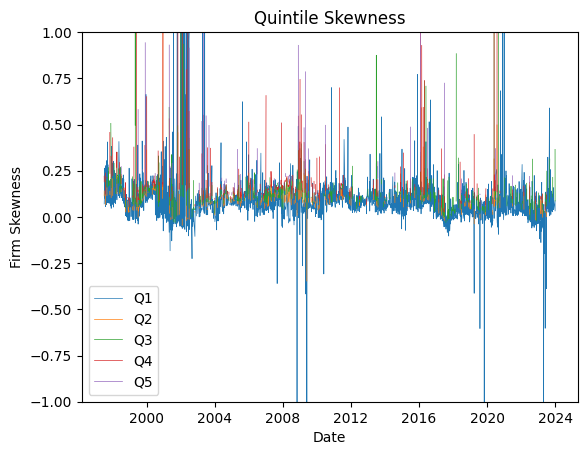

statistic,date,1,2,3,4,5
str,str,f64,f64,f64,f64,f64
"""count""","""2558""",2558.0,560.0,878.0,560.0,370.0
"""null_count""","""0""",0.0,1998.0,1680.0,1998.0,2188.0
"""mean""","""2010-07-05 12:20:49.726348""",0.041006,0.089369,0.152957,0.210392,0.224056
"""std""",null,2.8826,0.084066,0.456855,0.719952,0.183619
"""min""","""1997-07-01""",-145.169074,-0.346783,-0.070198,0.00419,0.072998
"""25%""","""2003-07-30""",0.038152,0.052806,0.081322,0.105774,0.154345
"""50%""","""2010-10-22""",0.081176,0.081049,0.113501,0.139916,0.193283
"""75%""","""2017-03-22""",0.128847,0.112088,0.153111,0.174948,0.235112
"""max""","""2023-12-29""",7.727232,1.050527,12.749503,16.192095,2.609044


In [36]:
# shows expected skewness
raw = (signal.group_by(["date", "quintile"]).agg(pl.col("IS2").mean()).pivot(
        values="IS2",
        index="date",
        columns="quintile", sort_columns=True
    )
    .sort("date")
    .with_columns(pl.exclude('date')))

dates= raw['date']

for col in raw.columns:
    if col != "date":
        plt.plot(dates, raw[col], label=f"Q{col}", linewidth=0.5)

plt.legend()
plt.xlabel("Date")

plt.ylabel("Firm Skewness")
plt.ylim(-1, 1)
plt.title("Quintile Skewness")
plt.show()
raw.describe()

In [29]:
vw = (
    signal.group_by(["date", "quintile"])
      .agg([
          (pl.col("return") * pl.col("mktcap_lag")).sum().alias("num"),
          pl.col("mktcap_lag").sum().alias("den"),
      ])
      .with_columns([
          (pl.col("num") / pl.col("den")).alias("vwret")
      ])
      .select(["date", "quintile", "vwret"])
)

vw_ts = vw.pivot(
    values="vwret",
    index="date",
    columns="quintile"
)
vw_ts

/tmp/ipykernel_1780511/612591466.py:13: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  vw_ts = vw.pivot(


date,3,1,4,2,5
date,f64,f64,f64,f64,f64
2003-07-30,-0.009524,0.0,0.003984,0.0,null
2004-01-30,-0.005677,0.000575,0.003799,0.003725,0.003438
2019-02-08,null,0.0,null,null,null
2022-04-29,-0.025651,-0.030918,-0.02661,-0.030763,-0.02757
2005-04-01,null,-0.00504,null,null,null
…,…,…,…,…,…
2011-01-06,null,0.0,null,null,null
2017-07-25,null,0.0,null,null,null
2010-12-09,null,0.00157,null,null,null


/tmp/ipykernel_1780511/430862856.py:5: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  ew = (signal.group_by(["date", "quintile"]).agg(pl.col("cum_ret").mean()).pivot(


shape: (2_558, 7)
┌────────────┬───────────┬───────────┬───────────┬───────────┬──────────┬───────────┐
│ date       ┆ 1         ┆ 2         ┆ 3         ┆ 4         ┆ 5        ┆ spread    │
│ ---        ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---      ┆ ---       │
│ date       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64      ┆ f64       │
╞════════════╪═══════════╪═══════════╪═══════════╪═══════════╪══════════╪═══════════╡
│ 1997-07-01 ┆ 0.002401  ┆ 0.004671  ┆ -0.005691 ┆ 0.10536   ┆ null     ┆ null      │
│ 1997-07-02 ┆ 0.063181  ┆ 0.00462   ┆ null      ┆ 0.176418  ┆ null     ┆ null      │
│ 1997-07-07 ┆ 0.054472  ┆ null      ┆ -0.005691 ┆ null      ┆ null     ┆ null      │
│ 1997-07-09 ┆ 0.051342  ┆ null      ┆ null      ┆ null      ┆ null     ┆ null      │
│ 1997-07-15 ┆ 0.051342  ┆ null      ┆ null      ┆ null      ┆ null     ┆ null      │
│ …          ┆ …         ┆ …         ┆ …         ┆ …         ┆ …        ┆ …         │
│ 2023-11-28 ┆ -6.470325 ┆ null     

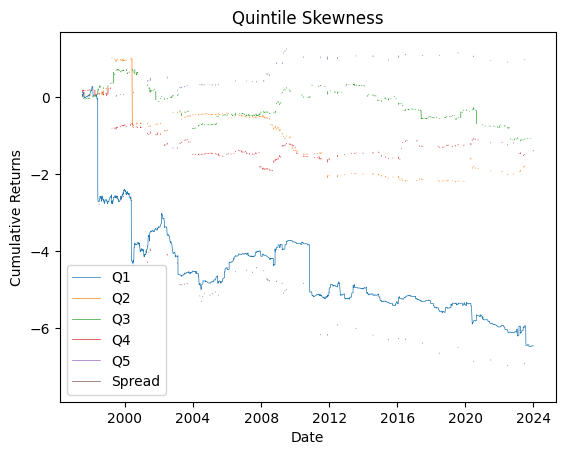

In [30]:
signal = signal.group_by(['date', 'quintile']).agg(pl.col('return').mean().alias('quint_ret')).sort(['quintile', 'date'])
signal = signal.with_columns(pl.col('quint_ret').log1p().cum_sum().over('quintile').alias('cum_ret'))


ew = (signal.group_by(["date", "quintile"]).agg(pl.col("cum_ret").mean()).pivot(
        values="cum_ret",
        index="date",
        columns="quintile", sort_columns=True
    )
    .sort("date")
    .with_columns(pl.exclude('date')))

ew = ew.with_columns((pl.col('1')-pl.col('5')).alias('spread'))
print(ew)

dates= ew['date']

for col in ew.columns:
    if col != "date" and col != 'spread':
        plt.plot(dates, ew[col], label=f"Q{col}", linewidth=0.5)
    if col == "spread":
        plt.plot(dates, ew[col], label=f"Spread", linewidth=0.5)

plt.legend()
plt.xlabel("Date")
# plt.ylim(-1,1)
plt.ylabel("Cumulative Returns")
plt.title("Quintile Skewness")
plt.show()

In [31]:
# does vol scaling


# 1. Calculate Rolling Volatility (using a 12-month window as an example)
# It is vital to sort by barrid and date for the rolling window to work
monthly_df = monthly_df.sort(["barrid", "date"])

monthly_df = monthly_df.with_columns(
    pl.col("return")
    .rolling_std(window_size=12)
    .over("barrid")
    .alias("vol")
)

# 2. Apply Signal Scaling
# We use a small epsilon or fill_null to avoid division by zero/nulls
signal_scaled = monthly_df.with_columns(
    (pl.col("IS2") / pl.col("vol")).alias("scaled_IS2")
).filter(pl.col("scaled_IS2").is_not_null() & pl.col("scaled_IS2").is_finite())

# 3. Create Quintiles based on the SCALED signal
signal_scaled = signal_scaled.with_columns(
    pl.col("scaled_IS2").rank(method="average").over("date").alias("rank")
)

signal_scaled = signal_scaled.with_columns(
    ((pl.col("rank") / pl.col("scaled_IS2").count().over("date") * 5).ceil().cast(pl.Int32))
    .alias("quintile")
)

# 4. Aggregate Equal-Weighted Returns per Quintile
# Even though the signal is scaled, we usually calculate EW returns 
# of the resulting buckets to see the effect of the scaling.
quintile_rets = (
    signal_scaled.group_by(["date", "quintile"])
    .agg(pl.col("return").mean().alias("quint_ret"))
    .sort(["date", "quintile"])
)

# 5. Cumulative Returns for plotting
ew_final = (
    quintile_rets.with_columns(
        pl.col("quint_ret").log1p().cum_sum().over("quintile").alias("cum_ret")
    )
    .pivot(values="cum_ret", index="date", on="quintile", sort_columns=True)
    .sort("date")
)

# 6. Calculate the Long/Short Spread
ew_final = ew_final.with_columns((pl.col('1') - pl.col('5')).alias('spread'))

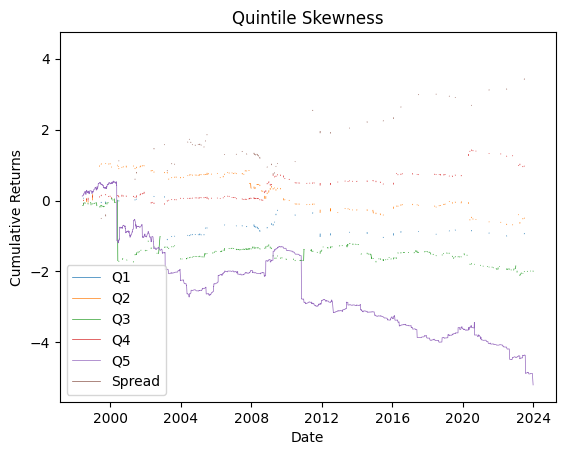

In [32]:
ew_final


dates= ew_final['date']

for col in ew_final.columns:
    if col != "date" and col != 'spread':
        plt.plot(dates, ew_final[col], label=f"Q{col}", linewidth=0.5)
    if col == "spread":
        plt.plot(dates, ew_final[col], label=f"Spread", linewidth=0.5)

plt.legend()
plt.xlabel("Date")
# plt.ylim(-1,1)
plt.ylabel("Cumulative Returns")
plt.title("Quintile Skewness")
plt.show()